# boamotion — building blocks

The pieces the analysis is assembled from: the parameter object, the synthetic test
recording, and the frame reader. Run **Imports** first, then any section on its own.

For what the analysis actually computes and what each parameter changes, see
[`HOW_IT_WORKS.md`](../HOW_IT_WORKS.md).

## Imports

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from boamotion import Params, load_frames, synthetic_recording

work_dir = Path(tempfile.mkdtemp(prefix="boamotion-"))
work_dir

WindowsPath('C:/Users/roman/AppData/Local/Temp/boamotion-fuwr3a91')

## 1. Parameters

`Params` holds every setting of an analysis. It can be built from keyword arguments,
changed afterwards attribute by attribute, or read from a file.

### 1.1 Defaults

Constructed empty, it carries the defaults of the original MUSCLEMOTION macro.

In [2]:
Params()

Params(framerate=100.0, speed_window=2, reference_frame=None, ref_search_start=1, ref_search_stop=300, n_low_values=20, n_unity_values=10, noise_reduction=True, mask_start_frame=1, mask_end_frame=None, transient_analysis=True, peak_window=20, peak_threshold=30.0, percentages=(10, 50, 90), baseline_threshold=2.0, baseline_n_points=5, high_freq_baseline=True, legacy=True)

In [3]:
defaults = Params()
print("frame rate       :", defaults.framerate, "fps")
print("time per frame   :", defaults.sampling_interval_ms, "ms")
print("reference frame  :", defaults.reference_frame, "(None means detect it automatically)")

frame rate       : 100.0 fps
time per frame   : 10.0 ms
reference frame  : None (None means detect it automatically)


### 1.2 Setting parameters

Keyword arguments for the values you know up front, attributes for anything you change
later. Both are checked.

In [4]:
params = Params(framerate=25, peak_threshold=50, high_freq_baseline=False)
params.peak_window = 20
params

Params(framerate=25, speed_window=2, reference_frame=None, ref_search_start=1, ref_search_stop=300, n_low_values=20, n_unity_values=10, noise_reduction=True, mask_start_frame=1, mask_end_frame=None, transient_analysis=True, peak_window=20, peak_threshold=50, percentages=(10, 50, 90), baseline_threshold=2.0, baseline_n_points=5, high_freq_baseline=False, legacy=True)

### 1.3 Saving and loading

Writing the parameters next to a result is what makes that result reproducible later. The
file is plain YAML, so it can also be written by hand or generated for a batch of jobs.

In [6]:
params_file = params.to_yaml(work_dir / "params.yaml")
print(params_file.read_text())

framerate: 25
speed_window: 2
reference_frame: null
ref_search_start: 1
ref_search_stop: 300
n_low_values: 20
n_unity_values: 10
noise_reduction: true
mask_start_frame: 1
mask_end_frame: null
transient_analysis: true
peak_window: 20
peak_threshold: 50
percentages:
- 10
- 50
- 90
baseline_threshold: 2.0
baseline_n_points: 5
high_freq_baseline: false
legacy: true



In [7]:
Params.from_yaml(params_file) == params

True

### 1.4 Validation

Impossible settings are refused immediately rather than producing puzzling results much
later, and a mistyped name in a file is an error rather than a silently ignored line.

In [8]:
try:
    Params(framerate=0)
except ValueError as error:
    print(error)

framerate must be positive, got 0


In [9]:
typo_file = work_dir / "typo.yaml"
typo_file.write_text("frame_rate: 25\n", encoding="utf-8")

try:
    Params.from_yaml(typo_file)
except ValueError as error:
    print(error)

unknown parameter(s): frame_rate. Valid names are: baseline_n_points, baseline_threshold, framerate, high_freq_baseline, legacy, mask_end_frame, mask_start_frame, n_low_values, n_unity_values, noise_reduction, peak_threshold, peak_window, percentages, ref_search_start, ref_search_stop, reference_frame, speed_window, transient_analysis


## 2. A synthetic recording

`synthetic_recording()` generates a beating movie whose peak frames, rest frames and beat
period are known exactly. It lets the analysis be tested against answers we chose
ourselves, and stands in for a real recording while developing.

### 2.1 Generating one

`noise` adds Gaussian camera noise as a fraction of full brightness and `seed` makes it
reproducible. Use `noise=0` for a perfectly clean recording.

In [10]:
recording = synthetic_recording(noise=0.01, seed=0)
recording

SyntheticRecording(100 frames, 80 x 64, 4 beats at 25.0 fps)

In [11]:
print("frames          :", recording.n_frames)
print("frames per beat :", recording.frames_per_beat)
print("beat interval   :", recording.beat_interval_ms, "ms")
print("peaks at frames :", recording.peak_frames)
print("first rest frame:", recording.rest_frames[0])

frames          : 100
frames per beat : 25
beat interval   : 1000.0 ms
peaks at frames : (16, 41, 66, 91)
first rest frame: 1


### 2.2 Looking at the frames

A bright blob shifts sideways once per beat, next to a second blob that never moves. Frame
numbers are 1-based throughout the package, hence the `- 1` when indexing the array.

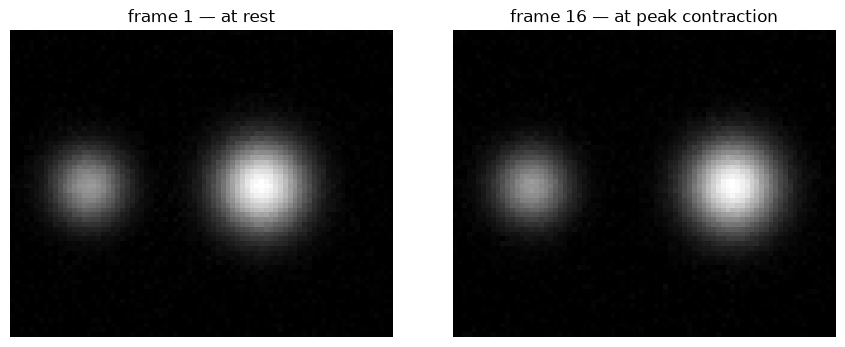

In [12]:
rest_frame = recording.rest_frames[0]
peak_frame = recording.peak_frames[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(recording.frames[rest_frame - 1], cmap="gray")
axes[0].set_title(f"frame {rest_frame} — at rest")
axes[1].imshow(recording.frames[peak_frame - 1], cmap="gray")
axes[1].set_title(f"frame {peak_frame} — at peak contraction")
axes[0].axis("off")
axes[1].axis("off")
fig.tight_layout()

### 2.3 The difference image

This is the entire idea behind the measurement. Subtract the resting frame from a frame of
interest and take the absolute value: the stationary blob disappears, and only what moved
lights up. Averaging this image over all pixels gives **one point** of the contraction
trace.

mean over all pixels: 2145.9614


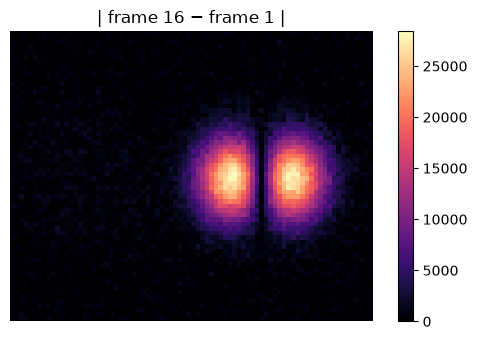

In [13]:
rest = recording.frames[rest_frame - 1].astype(np.float32)
peak = recording.frames[peak_frame - 1].astype(np.float32)
difference = np.abs(peak - rest)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
shown = ax.imshow(difference, cmap="magma")
ax.set_title(f"| frame {peak_frame} − frame {rest_frame} |")
ax.axis("off")
fig.colorbar(shown, ax=ax)
fig.tight_layout()

print("mean over all pixels:", difference.mean())

## 3. Reading a recording from disk

Real recordings arrive as one TIFF file per frame. `load_frames()` opens such a directory
and reads frames on demand, so memory use does not grow with the length of the recording.

### 3.1 Writing the synthetic recording out

In [14]:
movie_dir = recording.write(work_dir / "synthetic_movie")
sorted(path.name for path in movie_dir.iterdir())[:4]

['frame_0001.tif', 'frame_0002.tif', 'frame_0003.tif', 'frame_0004.tif']

### 3.2 Opening it

In [15]:
frames = load_frames(movie_dir)
frames

FrameSequence('synthetic_movie', 100 frames, 80 x 64, uint16)

In [16]:
print("frames :", frames.n_frames)
print("size   :", frames.shape, "(height, width)")
print("dtype  :", frames.dtype)

frames : 100
size   : (64, 80) (height, width)
dtype  : uint16


### 3.3 Reading individual frames

Indexing reads one file, iteration walks the recording in order. Only the first frame is
read when the recording is opened, so nothing is loaded until it is asked for.

In [17]:
first = frames[0]
last = frames[-1]
print("first frame:", first.shape, first.dtype)
print("same data as the generated array:", np.array_equal(first, recording.frames[0]))

first frame: (64, 80) uint16
same data as the generated array: True


## 4. Preview: what this adds up to

The three lines below are the core measurement written out by hand — not the package's
implementation, which arrives in later steps together with automatic reference-frame
detection, the pixel mask and the peak analysis. It is here to show that the pieces above
already reach a contraction trace.

Dashed lines mark the peak frames the recording was built with.

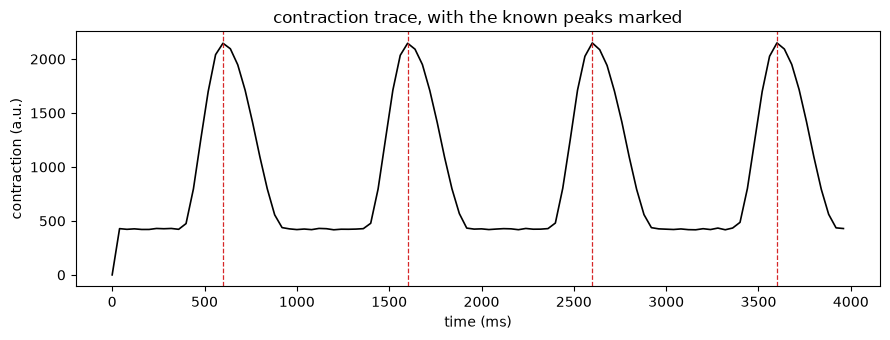

In [18]:
reference = frames[recording.rest_frames[0] - 1].astype(np.float32)
trace = np.array([np.abs(frame.astype(np.float32) - reference).mean() for frame in frames])
time_ms = np.arange(len(trace)) * (1000.0 / recording.framerate)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(time_ms, trace, color="black", linewidth=1.2)
for frame_number in recording.peak_frames:
    ax.axvline(
        (frame_number - 1) * 1000.0 / recording.framerate,
        color="tab:red",
        linestyle="--",
        linewidth=0.9,
    )
ax.set_xlabel("time (ms)")
ax.set_ylabel("contraction (a.u.)")
ax.set_title("contraction trace, with the known peaks marked")
fig.tight_layout()

Four humps, one per beat, each centred on a dashed line.

**The trace does not return to zero between beats** — it settles around 400-500. That is
the noise floor, and it is expected. This recording was generated with `noise=0.01`, so
every frame carries its own independent noise; two frames that are both at rest still
differ by that noise, and because the measurement takes the *absolute* difference those
differences cannot cancel out. They average to a positive number, here about 20% of the
peak height. Regenerate with `noise=0` and the trace reaches exactly zero at every resting
frame.

The one point that is exactly zero is the first, where the reference frame is compared
against itself.

This is what the pixel mask exists for. Around three quarters of this frame is dark
background that never moves but still contributes noise to every average, both lifting the
baseline and shrinking the contraction relative to it. Restricting the mean to the pixels
that actually move removes most of that floor — which is the next part of the analysis to
be built.